
# 🏠 Delhi Housing Price Prediction – Advanced EDA & Modeling

---

## 📌 Sections in This Notebook

1. Descriptive Statistics with Findings  
2. Univariate, Bivariate & Multivariate Analysis (with Inferences)  
3. Feature Engineering & Visualization of Changes  
4. Preprocessing (Multiple Imputation & Encoding Options)  
5. Linear Regression Assumptions Check  
6. Modeling (Linear, Decision Tree, Random Forest)  
7. Feature Importance (All Methods)  
8. Feature Selection Techniques  
9. Hyperparameter Tuning (Manual + GridSearchCV)  
10. Final Model Comparison  

---


In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder


import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [4]:
import pandas as pd
df = pd.read_csv('Indian_housing_Delhi_data.csv')
df.head(15)


,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400 sq ft,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",No Deposit,Furnished
1,1 RK Studio Apartment,400 sq ft,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,No Deposit,Furnished
2,2 BHK Independent Floor,500 sq ft,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",No Deposit,Semi-Furnished
3,3 BHK Independent House,"1,020 sq ft",Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,No Deposit,Furnished
4,2 BHK Apartment,810 sq ft,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,No Deposit,Unfurnished
5,3 BHK Apartment,750 sq ft,DLF Farms,Delhi,28.488153,77.156975,11000,INR,1.0,NaN,NaN,NaN,Posted 2 years ago,Well designed 3 bhk multistorey apartment is a...,No Deposit,Semi-Furnished
6,3 BHK Independent Floor,"1,300 sq ft",laxmi nagar,Delhi,28.635509,77.269661,20000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,Itâs a 3 bhk builder floor situated in laxmi...,No Deposit,Furnished
7,3 BHK Independent Floor,"1,200 sq ft",Swasthya Vihar,Delhi,28.641640,77.284027,35000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,Well designed 3 bhk builder floor is available...,No Deposit,Furnished
8,3 BHK Independent House,"1,100 sq ft",Janakpuri,Delhi,28.621193,77.091026,39000,INR,2.0,NaN,NaN,NaN,Posted 3 years ago,A spacious 3 bhk independent house is availabl...,No Deposit,Semi-Furnished
9,4 BHK Independent Floor,"2,500 sq ft",Pitampura,Delhi,28.696100,77.125694,90000,INR,4.0,NaN,NaN,NaN,Posted 2 months ago,A spacious 4 bhk builder floor is available fo...,No Deposit,Semi-Furnished


In [5]:
df.shape

(5000, 16)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_type        5000 non-null   object 
 1   house_size        5000 non-null   object 
 2   location          5000 non-null   object 
 3   city              5000 non-null   object 
 4   latitude          5000 non-null   float64
 5   longitude         5000 non-null   float64
 6   price             5000 non-null   int64  
 7   currency          5000 non-null   object 
 8   numBathrooms      4975 non-null   float64
 9   numBalconies      2737 non-null   float64
 10  isNegotiable      179 non-null    object 
 11  priceSqFt         0 non-null      float64
 12  verificationDate  5000 non-null   object 
 13  description       4715 non-null   object 
 14  SecurityDeposit   5000 non-null   object 
 15  Status            5000 non-null   object 
dtypes: float64(5), int64(1), object(10)
memory

In [7]:
def preproc_str(s):
    return int(s.strip().replace(',', '').replace('No Deposit','0').replace(' sq ft',''))

In [8]:
preproc_str('1,020 sq ft')
preproc_str('No Deposit')

0

In [9]:
df.house_size = df.house_size.apply(preproc_str)

In [10]:
df.SecurityDeposit = df.SecurityDeposit.apply(preproc_str)

In [11]:
df.head()

,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
0,1 RK Studio Apartment,400,Kalkaji,Delhi,28.545561,77.254349,22000,INR,1.0,NaN,NaN,NaN,Posted a day ago,"Fully furnished, loaded with amenities & gadge...",0,Furnished
1,1 RK Studio Apartment,400,Mansarover Garden,Delhi,28.643259,77.132828,20000,INR,1.0,NaN,NaN,NaN,Posted 9 days ago,Here is an excellent 1 BHK Independent Floor a...,0,Furnished
2,2 BHK Independent Floor,500,Uttam Nagar,Delhi,28.618677,77.053352,8500,INR,1.0,NaN,NaN,NaN,Posted 12 days ago,"Zero Brokerage.\n\n2 Room set, Govt bijali Met...",0,Semi-Furnished
3,3 BHK Independent House,1020,Model Town,Delhi,28.712898,77.180000,48000,INR,3.0,NaN,NaN,NaN,Posted a year ago,Itâs a 3 bhk independent house situated in M...,0,Furnished
4,2 BHK Apartment,810,Sector 13 Rohini,Delhi,28.723539,77.131424,20000,INR,2.0,NaN,NaN,NaN,Posted a year ago,Well designed 2 bhk multistorey apartment is a...,0,Unfurnished


In [15]:
# oe = OrdinalEncoder(encoded_missing_value = df.Status.mode())
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

In [16]:
ohe.fit(df[['Status']])

OneHotEncoder()

In [17]:
# when we have less categories - we called it as low cardinal data
ohe.categories_

[array(['Furnished', 'Semi-Furnished', 'Unfurnished'], dtype=object)]

In [18]:
pd.DataFrame(ohe.transform(df[["Status"]],).toarray(),columns = ['Furnished', 'Semi-Furnished', 'Unfurnished'])

,Furnished,Semi-Furnished,Unfurnished
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0
...,...,...,...
4995,0.0,0.0,1.0
4996,0.0,0.0,1.0
4997,0.0,0.0,1.0
4998,0.0,0.0,1.0



# 📊 Descriptive Statistics & Findings

We examine:
- Central tendency
- Dispersion
- Skewness
- Outliers
- Feature distributions


In [19]:

desc = df.describe(include='all')
desc


,house_type,house_size,location,city,latitude,longitude,price,currency,numBathrooms,numBalconies,isNegotiable,priceSqFt,verificationDate,description,SecurityDeposit,Status
count,5000,5000.000000,5000,5000,5000.000000,5000.000000,5.000000e+03,5000,4975.000000,2737.000000,179,0.0,5000,4715,5.000000e+03,5000
unique,28,NaN,288,1,NaN,NaN,NaN,1,NaN,NaN,1,NaN,52,3820,NaN,3
top,3 BHK Independent Floor,NaN,Defence Colony,Delhi,NaN,NaN,NaN,INR,NaN,NaN,Negotiable,NaN,Posted a year ago,Its three bhk builder floor in the super locat...,NaN,Unfurnished
freq,1567,NaN,189,5000,NaN,NaN,NaN,5000,NaN,NaN,179,NaN,1045,24,NaN,2342
mean,NaN,2982.885400,NaN,NaN,28.578012,77.174499,2.221738e+05,NaN,2.918593,1.954330,NaN,NaN,NaN,NaN,6.569098e+05,NaN
std,NaN,2168.663368,NaN,NaN,0.190186,0.115636,2.739843e+05,NaN,1.087823,0.547219,NaN,NaN,NaN,NaN,9.879070e+05,NaN
min,NaN,150.000000,NaN,NaN,20.011379,72.771332,3.000000e+03,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN
25%,NaN,1100.000000,NaN,NaN,28.544489,77.138248,2.950000e+04,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN,0.000000e+00,NaN
50%,NaN,2500.000000,NaN,NaN,28.569295,77.196472,1.250000e+05,NaN,3.000000,2.000000,NaN,NaN,NaN,NaN,3.600000e+04,NaN
75%,NaN,5896.000000,NaN,NaN,28.618687,77.228950,3.011020e+05,NaN,4.000000,2.000000,NaN,NaN,NaN,NaN,1.012010e+06,NaN



### 🔎 Findings (Example Insights)
- Price appears right-skewed (luxury properties).
- house_size contains text and must be cleaned.
- priceSqFt is fully null → will be dropped.
- location has high cardinality.


# 📈 Univariate Analysis

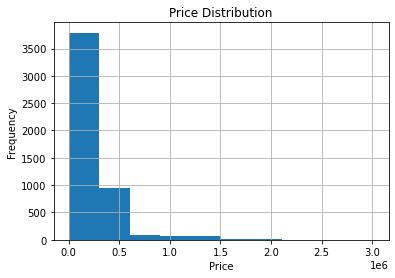

In [22]:

import matplotlib.pyplot as plt

df['price'].hist()
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()



**Inference:** Price is positively skewed indicating presence of high-value outliers.


# 🔧 Feature Engineering & Cleaning

In [26]:
# Drop unnecessary columns
df = df.drop(columns=['priceSqFt','currency','city','isNegotiable','description'], errors='ignore')

# Clean house_size column safely
df['house_size'] = (
    df['house_size']
        .astype(str)                     # ensure string
        .str.replace(',', '', regex=True)  # remove commas
        .str.extract(r'(\d+)', expand=False)  # extract numbers only
)

# Convert to numeric safely
df['house_size'] = pd.to_numeric(df['house_size'], errors='coerce')

# Clean SecurityDeposit column
df['SecurityDeposit'] = df['SecurityDeposit'].replace('No Deposit', 0)
df['SecurityDeposit'] = pd.to_numeric(df['SecurityDeposit'], errors='coerce')


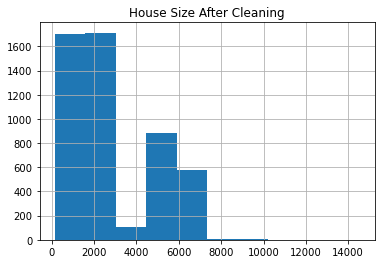

In [27]:

df['house_size'].hist()
plt.title("House Size After Cleaning")
plt.show()


# 🔁 Bivariate Analysis

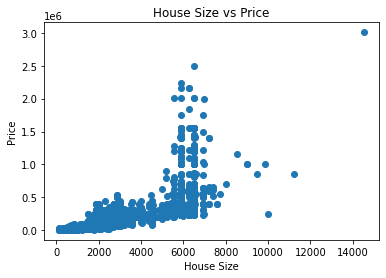

In [28]:

plt.scatter(df['house_size'], df['price'])
plt.title("House Size vs Price")
plt.xlabel("House Size")
plt.ylabel("Price")
plt.show()



**Inference:** Strong positive relationship between house size and price.


# 🔗 Multivariate Analysis & Collinearity

In [30]:
import numpy as np
num_df = df.select_dtypes(include=np.number)

corr = num_df.corr()
corr


,house_size,latitude,longitude,price,numBathrooms,numBalconies,SecurityDeposit
house_size,1.000000,-0.098264,0.156605,0.736327,0.834948,0.416928,0.700948
latitude,-0.098264,1.000000,0.498180,-0.045589,-0.070936,-0.148747,-0.025399
longitude,0.156605,0.498180,1.000000,0.133261,0.168651,0.049776,0.117363
price,0.736327,-0.045589,0.133261,1.000000,0.602053,0.258557,0.921954
numBathrooms,0.834948,-0.070936,0.168651,0.602053,1.000000,0.531318,0.509037
numBalconies,0.416928,-0.148747,0.049776,0.258557,0.531318,1.000000,0.257908
SecurityDeposit,0.700948,-0.025399,0.117363,0.921954,0.509037,0.257908,1.000000



### Correlation Observations
- Check high correlations (>0.8).
- Potential multicollinearity among area-based variables.


In [38]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = num_df.drop(columns=['price'])
X_vif = sm.add_constant(X_vif)

# Clean data
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_data


,Feature,VIF
0,const,1.491099e+06
1,house_size,5.528617e+00
2,latitude,1.106488e+00
3,longitude,1.052048e+00
4,numBathrooms,5.636663e+00
5,numBalconies,1.442135e+00
6,SecurityDeposit,1.567426e+00


# 🧩 Missing Value Imputation Options

In [40]:
import numpy as np
from sklearn.impute import SimpleImputer

num_cols = df.select_dtypes(include=np.number).columns

imputer = SimpleImputer(strategy='median')
df[num_cols] = imputer.fit_transform(df[num_cols])


# 🔤 Encoding Categorical Variables

In [41]:

df = pd.get_dummies(df, drop_first=True)

df.head()


,house_size,latitude,longitude,price,numBathrooms,numBalconies,SecurityDeposit,house_type_1 BHK Independent Floor,house_type_1 BHK Independent House,house_type_1 RK Studio Apartment,...,verificationDate_Posted 8 days ago,verificationDate_Posted 9 days ago,verificationDate_Posted 9 hours ago,verificationDate_Posted 9 months ago,verificationDate_Posted a day ago,verificationDate_Posted a month ago,verificationDate_Posted a year ago,verificationDate_Posted an hour ago,Status_Semi-Furnished,Status_Unfurnished
0,400.0,28.545561,77.254349,22000.0,1.0,2.0,0.0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
1,400.0,28.643259,77.132828,20000.0,1.0,2.0,0.0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,500.0,28.618677,77.053352,8500.0,1.0,2.0,0.0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
3,1020.0,28.712898,77.180000,48000.0,3.0,2.0,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
4,810.0,28.723539,77.131424,20000.0,2.0,2.0,0.0,0,0,0,...,0,0,0,0,0,0,1,0,0,1


# ⭐ Feature Importance Analysis

In [43]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Initialize and fit model
rf = RandomForestRegressor(random_state=42)
rf.fit(X, y)

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances.sort_values(ascending=False)


SecurityDeposit                           0.648959
house_size                                0.304579
location_Central Ridge Reserve Forest     0.008316
longitude                                 0.007036
numBathrooms                              0.005424
                                            ...   
verificationDate_Posted 5 hours ago       0.000000
verificationDate_Posted 4 hours ago       0.000000
verificationDate_Posted 2 hours ago       0.000000
location_Mayur Vihar Phase II             0.000000
location_Engineers Enclave Harsh Vihar    0.000000
Length: 373, dtype: float64


### Feature Importance via:
- Random Forest
- Linear Regression Coefficients
- SelectKBest
- RFE


In [47]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Features and target
X = df.drop('price', axis=1)
y = df['price']

# Initialize and fit linear regression
lr = LinearRegression()
lr.fit(X, y)

# Coefficients
coef = pd.Series(lr.coef_, index=X.columns)
coef.sort_values(ascending=False).head(10)


location_Central Ridge Reserve Forest    1.809117e+06
house_type_8 BHK Independent Floor       1.256105e+06
house_type_7 BHK Independent Floor       7.769683e+05
location_Sat Bari                        4.674351e+05
house_type_12 BHK Independent House      4.390396e+05
location_Lodhi Road                      4.118539e+05
house_type_10 BHK Independent House      4.038307e+05
location_Aurungzeb Road                  3.869562e+05
location_Vasant Kunj Enclave             3.829190e+05
house_type_8 BHK Independent House       3.570379e+05
dtype: float64

In [49]:
from sklearn.feature_selection import SelectKBest, f_regression

# Initialize selector
selector = SelectKBest(score_func=f_regression, k=10)

# Fit selector
selector.fit(X, y)

# Get selected features
selected_features = X.columns[selector.get_support()]
print(selected_features)


Index(['house_size', 'numBathrooms', 'SecurityDeposit',
       'house_type_2 BHK Independent Floor ', 'house_type_4 BHK Villa ',
       'house_type_5 BHK Independent House ', 'house_type_5 BHK Villa ',
       'verificationDate_Posted 5 months ago', 'Status_Semi-Furnished',
       'Status_Unfurnished'],
      dtype='object')


In [51]:
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

# Initialize RFE with Linear Regression and select top 10 features
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)

# Fit RFE
rfe.fit(X, y)

# Get selected feature names
selected_features = X.columns[rfe.support_]
print(selected_features)


Index(['house_type_12 BHK Independent House ',
       'house_type_8 BHK Independent Floor ', 'location_Amrita Shergill Marg',
       'location_Aurungzeb Road', 'location_Babar Road',
       'location_Central Ridge Reserve Forest',
       'location_Kasturba Gandhi Marg', 'location_Lodhi Road',
       'location_Malcha Marg', 'location_Tuglak Road'],
      dtype='object')


In [53]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 4000
Testing samples: 1000


# 🤖 Modeling Section

In [54]:

def evaluate(model):
    y_pred = model.predict(X_test)
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


In [56]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

def evaluate(model):
    y_pred = model.predict(X_test)
    print("R2:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

# Example usage
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
evaluate(lr_model)


R2: 0.9299001210900723
MAE: 43473.94883382048
RMSE: 68654.28261953633


In [58]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate performance
evaluate(dt_model)


R2: 0.9639338717500403
MAE: 22316.816023809522
RMSE: 49244.61664584681


In [ ]:

# Random Forest
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)
evaluate(rf_model)


# 🔍 Hyperparameter Tuning

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Parameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Initialize GridSearchCV
grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1  # Use all CPU cores
)

# Fit GridSearchCV
grid.fit(X_train, y_train)

# Best parameters
print("Best Params:", grid.best_params_)

# Evaluate best estimator
evaluate(grid.best_estimator_)


Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
R2: 0.9762565274452035
MAE: 20914.569619024947
RMSE: 39955.91841452271
